In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl

# ---- CONFIGURATION ----
# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300

# Check for and configure LaTeX if available (optional but professional)
# Uncomment this if you have LaTeX installed
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

# If not using LaTeX, use a clean serif font
# Try to use TeX fonts that are included with matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})

# Define a modern, colorblind-friendly palette with higher contrast
# Based on colorblindness-friendly scientific palettes like viridis
# and ones recommended by Nature and Science publications
COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

In [2]:
key_selected = "n"

# More descriptive and professionally formatted names
names = {
    "n": r"$\mathcal{D}$",          # Using calligraphic D for density
    "x": r"$\varepsilon$",           # Using proper epsilon symbol
    "s": r"$\mathcal{S}$",           # Calligraphic S
    "t": r"$\mathcal{T}$",           # Calligraphic T
    "g": r"$\mathcal{G}$",           # Calligraphic G
    "x2": r"$10\varepsilon$"         # 10 epsilon
}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
estimators_base = ["s", "g", "t", "x"]

In [3]:
configuration = '../configs/abacus/config_abacus.yaml'

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

In [4]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [5]:
#ic = load_dens(ic_dir, sim_name, ngrid)
import jax.numpy as jnp
pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

In [6]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()
analysis_cross_shot_AB = np.load(output_dir / f"{filename_prefix}_cross_shot_AB.npy", allow_pickle = True).item()


kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [7]:
direc = f"/users/odarwish/colabdata/results/{config['name']}/"
Ns = 3

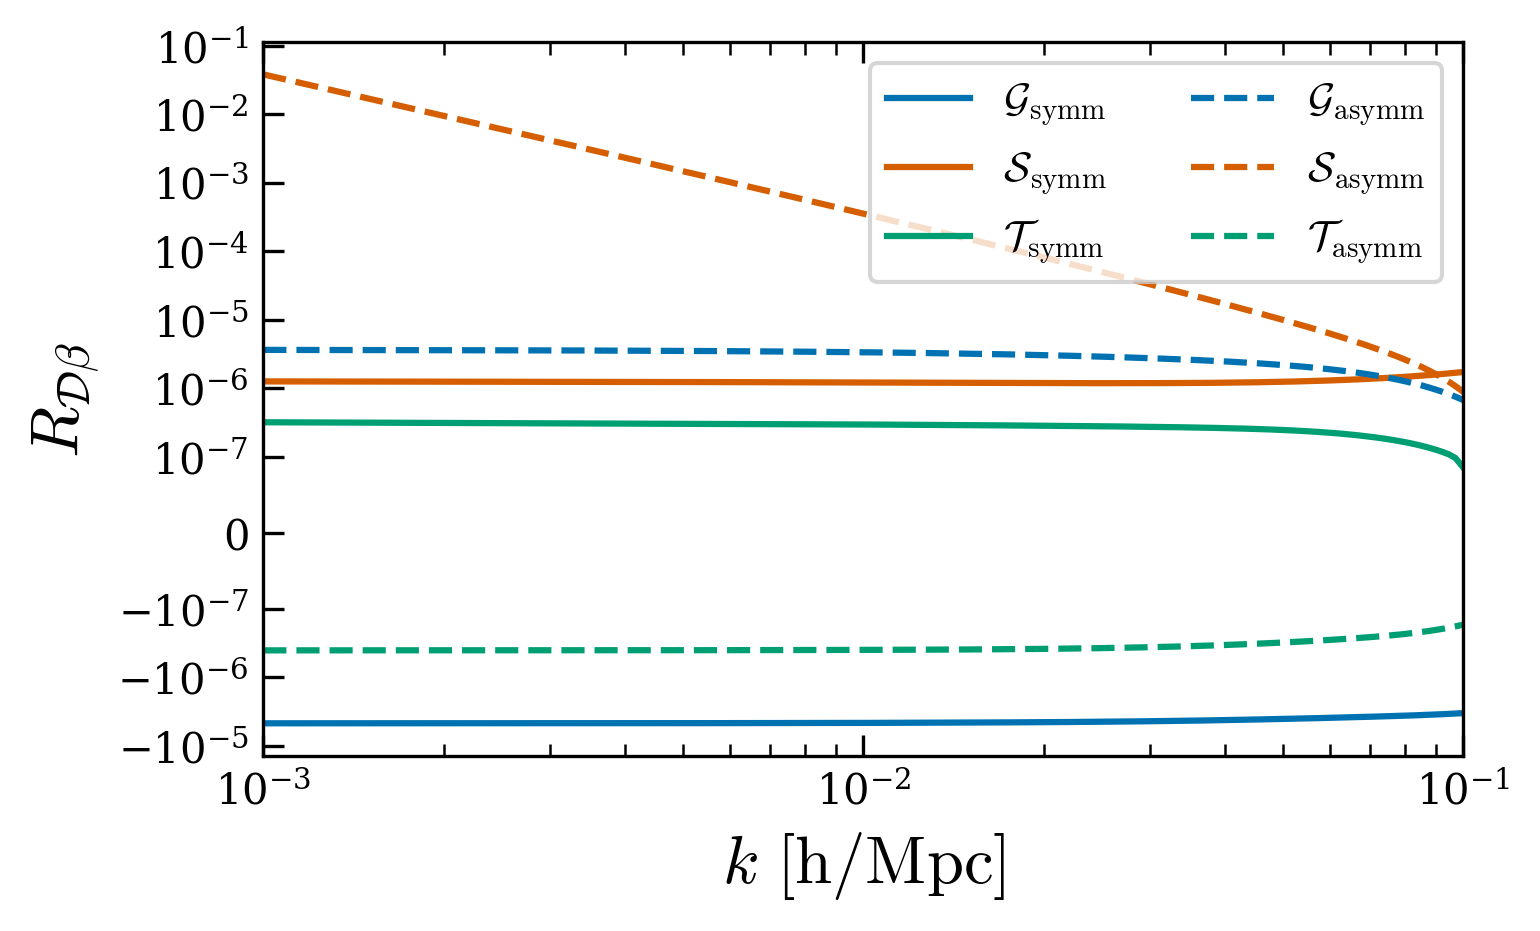

In [8]:
# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

i = 0
color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]


# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

keys = ["g", "s", "t", "ga", "sa", "ta"]
labels = [r"$\mathrm{\mathcal{G}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{G}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{asymm}}$"]
key = "n"

normalized = False

if normalized:
    N = out_normalization_AB[(key, key)]**-1.
else:
    N = 1
for i, k in enumerate(keys):
    color_ = COLORBLIND_PALETTE[i%3]
    R = out_normalization_AB[(key, k)]
    ax.loglog(Ks, N*(R), label = labels[i], color = color_, ls = "-" if i < 3 else "--")
    
ax.set_xlabel(r'$k \ \mathrm{[h/Mpc]}$', fontsize=16)

if normalized:
    ax.set_ylabel(r'$N_{\mathcal{D}\mathcal{D}}R_{{\mathcal{D}\beta}}$', fontsize=16)
else:
    ax.set_ylabel(r'$R_{{\mathcal{D}\beta}}$', fontsize=16)


ax.legend(ncol = 2, loc = "upper right")
ax.set_xlim(1e-3, 1e-1)
if normalized:
    ax.set_ylim(1e-5, 3)
else:
    #ax.set_ylim(-1e-7, 1e-7)
    pass

ax.set_yscale('symlog', linthresh = 1e-7)  # Adjust threshold based on your data
fig.savefig(f"/users/odarwish/long-modes/figures/responses.pdf", dpi = 300, bbox_inches='tight')
plt.show()
plt.close()

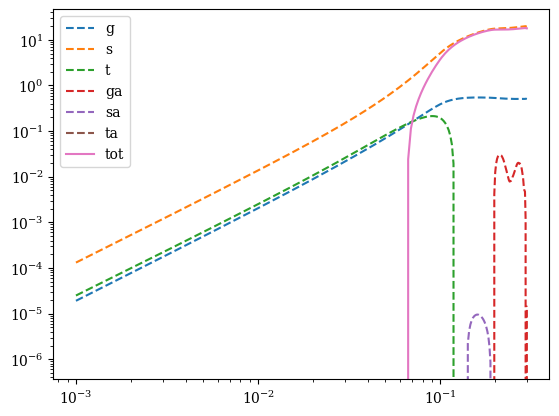

In [9]:
import jax
from jax import numpy as jnp
def symm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)+f(B, A, **kwargs))/2
def asymm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)-f(B, A, **kwargs))/2
def bs2_coev(b10):
  """
  Coevolution value of the bs2 parameter
  """
  return -2./7.*(b10-1)
def b2_fit(b10):
    return 2*(0.412-2.143*b10 + 0.929*b10**2 + 0.008*b10**3)
def br_formula(b1, z = 0.5):
    h = 0.6736
    H0 = h*100
    bias = 6.8*((1+z)*H0)**-1.*(b1-1) #formula 20 from Schmidt 2016
    return bias
def bGX(b10):
    factor = 1421/510
    return br_formula(b10)*factor
def bSX(b10):
    factor = 17/6
    return br_formula(b10)*factor
def bTX(b10):
    factor = 91/30
    return br_formula(b10)*factor
    
b1A = 1
b1B = 2
e = 1e-3
b1C = b1A
Cgbiases = {}
Cgbiases["g"] = lambda b1X, b1Y, e: (b1X+21/17*b2_fit(b1X)+e*bGX(b1X))*b1Y
Cgbiases["s"] = lambda b1X, b1Y, e: (b1X+e*bSX(b1X))*b1Y
Cgbiases["t"] = lambda b1X, b1Y, e: (b1X+7/2*bs2_coev(b1X)+e*bTX(b1X))*b1Y
shot_induced_term = analysis_cross_shot_AB[(key, key)]
N = out_normalization_AB[(key, key)]**-1.

Cg = {}
Cg["g"] = symm(Cgbiases["g"], b1A, b1B, e = e)
Cg["s"] = symm(Cgbiases["s"], b1A, b1B, e = e)
Cg["t"] = symm(Cgbiases["t"], b1A, b1B, e = e)
Cg["ga"] = asymm(Cgbiases["g"], b1A, b1B, e = e)
Cg["sa"] = asymm(Cgbiases["s"], b1A, b1B, e = e)
Cg["ta"] = asymm(Cgbiases["t"], b1A, b1B, e = e)

bias = 0.
for i, k in enumerate(keys):
    color_ = COLORBLIND_PALETTE[i%3]
    R = out_normalization_AB[(key, k)]
    partial = N*(R)*Cg[k]
    bias += partial
    plt.plot(Ks, (partial), label = k, ls = "--")
plt.loglog(Ks, (bias), label = "tot")
plt.legend()

In [10]:
import jax
import jax.numpy as jnp

# Fixed functions - these are fine as they are
def symm(f, A, B, e):
    return (f(A, B, e) + f(B, A, e)) / 2

def asymm(f, A, B, e):
    return (f(A, B, e) - f(B, A, e)) / 2

def bs2_coev(b10):
    return -2./7. * (b10 - 1)

def b2_fit(b10):
    return 2 * (0.412 - 2.143 * b10 + 0.929 * b10**2 + 0.008 * b10**3)

def br_formula(b1, z=0.5):
    h = 0.6736
    H0 = h * 100
    bias = 6.8 * ((1 + z) * H0)**-1. * (b1 - 1)
    return bias

def bGX(b10):
    factor = 1421/510
    return br_formula(b10) * factor

def bSX(b10):
    factor = 17/6
    return br_formula(b10) * factor

def bTX(b10):
    factor = 91/30
    return br_formula(b10) * factor

# Replace the dictionary with individual functions
def cg_g(b1X, b1Y, e):
    return (b1X + 21/17 * b2_fit(b1X) + e * bGX(b1X)) * b1Y

def cg_s(b1X, b1Y, e):
    return (b1X + e * bSX(b1X)) * b1Y

def cg_t(b1X, b1Y, e):
    return (b1X + 7/2 * bs2_coev(b1X) + e * bTX(b1X)) * b1Y

# Constants
b1A = 2.0
b1B = 1.0
e = 1e-3

# Create a dummy jax_out_normalization_AB array with random values for demonstration
# Replace with actual values
num_keys = 6  # For g, s, t, ga, sa, ta

shot_induced_term = analysis_cross_shot_AB[(key, key)]
N = np.array(out_normalization_AB[(key, key)]**-1.)
N[-22:] = 0
N = jnp.array(N)

jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
for i, k in enumerate(keys):
    jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)

# The JAX-compatible get_bias function
def get_bias_jax(v, zero = 0):
    b1A, b1B, e = v
    # Calculate all Cg values and store in an array
    f = (1-zero)
    cg_values = jnp.array([
        symm(cg_g, b1A, b1B, e)*f,  # g
        symm(cg_s, b1A, b1B, e)*f,  # s
        symm(cg_t, b1A, b1B, e)*f,  # t
        asymm(cg_g, b1A, b1B, e)*f, # ga
        asymm(cg_s, b1A, b1B, e), # sa
        asymm(cg_t, b1A, b1B, e)*f  # ta
    ])
    
    # Element-wise multiplication and sum
    # Each row of jax_out_normalization_AB corresponds to one 'key'
    partials = N * jax_out_normalization_AB * cg_values[:, jnp.newaxis]
    
    # Sum across keys to get the total bias
    bias = jnp.sum(partials, axis=0)
    
    return jnp.nan_to_num(bias)  # Returns a vector of size len(Ks)

def get_shot_cross():
    return shot_induced_term*N
    
def get_total_cross(v, Ks):
    cross_noise = get_shot_cross()
    return b1C*get_bias_jax(v)*plinf(Ks)+cross_noise

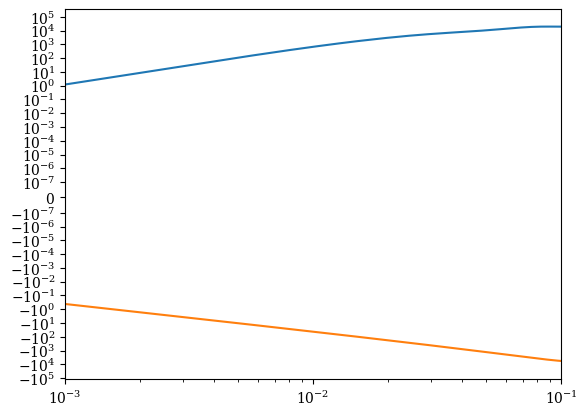

In [11]:
v = jnp.array([b1A, b1B, e])
signal = get_total_cross(v, Ks)

plt.plot(Ks, signal)
plt.loglog(Ks, get_shot_cross())
plt.yscale('symlog', linthresh = 1e-7) 
plt.xlim(1e-3, 1e-1)
plt.show()

In [12]:
jacobian = jax.jacobian(get_total_cross)
derivatives = jacobian(v, Ks)

In [13]:
derivatives_matrix = jnp.einsum('ki, kj -> kij', derivatives, derivatives)

In [14]:
fisher = 0.5*(derivatives_matrix/get_total_cross(v, Ks)[:, None, None])**2
diagonal_fisher = jnp.diagonal(fisher, axis1 = 1, axis2 = 2)
error_bar_single = diagonal_fisher**-0.5

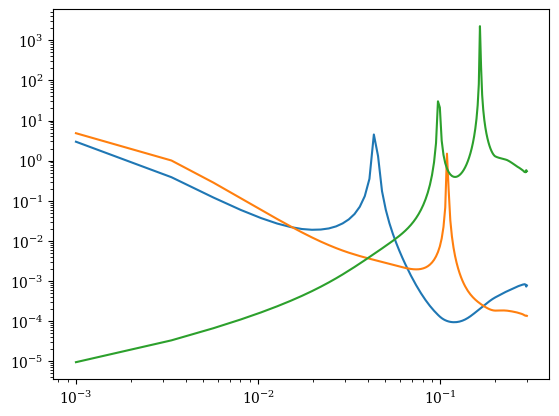

In [15]:
plt.loglog(Ks, error_bar_single[:, 0])
plt.loglog(Ks, error_bar_single[:, 1])
plt.loglog(Ks, error_bar_single[:, 2])
plt.show()

In [16]:
import jax
import jax.numpy as jnp


def safe_inv(C, eps=1e-8):
    """Safely invert a batch of matrices with regularization."""
    nK, nprobes, _ = C.shape
    reg_C = C + eps * jnp.eye(nprobes)[None, :, :]
    return jnp.linalg.inv(reg_C)

def fisher_per_mode(v, K_array, Cfunc, eps=1e-8):
    """
    Compute the Fisher matrix per mode for a general covariance matrix C,
    where Cfunc(K_array, v) returns (n_modes, nprobes, nprobes).
    """
    n_params = len(v)
    n_modes = len(K_array)

    # C: (n_modes, nprobes, nprobes)
    C = Cfunc(K_array, v)
    Cinv = safe_inv(C, eps)  # (n_modes, nprobes, nprobes)

    # Compute derivatives: dC_dv has shape (n_modes, nprobes, nprobes, n_params)
    dC_dv = jax.jacfwd(Cfunc, argnums=1)(K_array, v)  # (n_modes, nprobes, nprobes, n_params)

    # Fisher matrix per mode
    F = jnp.zeros((n_modes, n_params, n_params))
    for a in range(n_params):
        for b in range(n_params):
            # term_a: (n_modes, nprobes, nprobes)
            term_a = jnp.einsum('mij,mjk->mik', dC_dv[..., a], Cinv)
            term_b = jnp.einsum('mij,mjk->mik', dC_dv[..., b], Cinv)
            # product: (n_modes, nprobes, nprobes)
            product = jnp.einsum('mij,mjk->mik', term_a, term_b)
            # trace: (n_modes,)
            trace = jnp.einsum('mii->m', product)
            F = F.at[:, a, b].set(0.5 * trace)
    return F

In [17]:
from interpax import Interpolator1D
plinf_jax = Interpolator1D(gen_power[:,0], gen_power[:,1], method="cubic")

In [18]:
import jax
import jax.numpy as jnp

# Fixed functions - these are fine as they are
def symm(f, A, B, e):
    return (f(A, B, e) + f(B, A, e)) / 2

def asymm(f, A, B, e):
    return (f(A, B, e) - f(B, A, e)) / 2

def bs2_coev(b10):
    return -2./7. * (b10 - 1)

def b2_fit(b10):
    return 2 * (0.412 - 2.143 * b10 + 0.929 * b10**2 + 0.008 * b10**3)

def br_formula(b1, z=0.5):
    h = 0.6736
    H0 = h * 100
    bias = 6.8 * ((1 + z) * H0)**-1. * (b1 - 1)
    return bias

def bGX(b10):
    factor = 1421/510
    return br_formula(b10) * factor

def bSX(b10):
    factor = 17/6
    return br_formula(b10) * factor

def bTX(b10):
    factor = 91/30
    return br_formula(b10) * factor

# Replace the dictionary with individual functions
def cg_g(b1X, b1Y, e):
    return (b1X + 21/17 * b2_fit(b1X) + e * bGX(b1X)) * b1Y

def cg_s(b1X, b1Y, e):
    return (b1X + e * bSX(b1X)) * b1Y

def cg_t(b1X, b1Y, e):
    return (b1X + 7/2 * bs2_coev(b1X) + e * bTX(b1X)) * b1Y

# Constants
b1A = 1.0
b1B = 1.0
e = 1e-3

# Create a dummy jax_out_normalization_AB array with random values for demonstration
# Replace with actual values
num_keys = 6  # For g, s, t, ga, sa, ta

shot_induced_term = analysis_cross_shot_AB[(key, key)]
N = np.array(out_normalization_AB[(key, key)]**-1.)
N[-22:] = 0
N = jnp.array(N)

jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
for i, k in enumerate(keys):
    jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)

# The JAX-compatible get_bias function
def get_bias_jax(v, zero = 0):
    b1A, b1B, e = v
    # Calculate all Cg values and store in an array
    f = (1-zero)
    cg_values = jnp.array([
        symm(cg_g, b1A, b1B, e)*f,  # g
        symm(cg_s, b1A, b1B, e)*f,  # s
        symm(cg_t, b1A, b1B, e)*f,  # t
        asymm(cg_g, b1A, b1B, e)*f, # ga
        asymm(cg_s, b1A, b1B, e), # sa
        asymm(cg_t, b1A, b1B, e)*f  # ta
    ])
    
    # Element-wise multiplication and sum
    # Each row of jax_out_normalization_AB corresponds to one 'key'
    partials = N * jax_out_normalization_AB * cg_values[:, jnp.newaxis]
    
    # Sum across keys to get the total bias
    bias = jnp.sum(partials, axis=0)
    
    return jnp.nan_to_num(bias)  # Returns a vector of size len(Ks)

def get_shot_cross():
    return shot_induced_term*N
    
def get_total_cross(Ks, v):
    cross_noise = get_shot_cross()
    return b1C*get_bias_jax(v)*plinf_jax(Ks)+cross_noise

In [19]:
from torchquad import Simpson, set_up_backend
import jax.numpy as jnp
import numpy as np

set_up_backend("jax", data_type="float64")


@jax.jit
def Covariance_cross_only(K_array, v):
    n_probes = 1
    b1A, b1B, e = v
    P = plinf_jax(K_array)
    CAA = get_total_cross(Ks, v)
    # Stack into (n_modes, 2, 2)
    C = jnp.zeros((len(K_array), n_probes, n_probes))
    C = C.at[:, 0, 0].set(CAA)
    return C

# Constants
b1A = 1.0
b1B = 1.0
e = 1e-3

v = jnp.array([b1A, b1B, e])

K_array = Ks
F = fisher_per_mode(v, K_array, Covariance_cross_only)

n_params = len(v)

from interpax import Interpolator1D
import jax.numpy as jnp

def get_F_interp(K_array, Fmatrix):
    @jax.jit
    def F_interp(K_eval):
        # K_eval: scalar or array
        # Returns: (..., n_params, n_params)
        n_params = Fmatrix.shape[1]
        F_interpolated = [[Interpolator1D(K_array, Fmatrix[:, a, b], method='cubic') for b in range(n_params)] for a in range(n_params)]
        return jnp.stack([
            jnp.stack([F_interpolated[a][b](K_eval) for b in range(n_params)], axis=-1)
            for a in range(n_params)
        ], axis=-2)
    return F_interp

Finterp = get_F_interp(K_array, F)

integrator = Simpson()

K_min = k_min_analysis
K_max = k_max_analysis

F_integrated = jnp.zeros((n_params, n_params))

for a in range(n_params):
    for b in range(a, n_params):
        def scalar_integrand(K):
            # K: (N, 1)
            K = K.squeeze(-1)
            # Finterp should return (..., n_params, n_params)
            return K**2 * Finterp(K)[..., a, b]
        result = integrator.integrate(
            scalar_integrand,
            dim=1,
            N=199,
            integration_domain=[[K_min, K_max]]
        )
        F_integrated = F_integrated.at[a, b].set(result)
        if a != b:
            F_integrated = F_integrated.at[b, a].set(result)

V = 1000 #Gpc^3 h^{-3}
# Multiply by prefactor (factor of 2 from mu integration)
F_integrated = F_integrated * (2 * V / (2 * np.pi)**2)

/users/odarwish/lenscarf/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


In [20]:
F_integrated

Array([[1.07064921, 1.06485118, 0.        ],
       [1.06485118, 1.06161065, 0.        ],
       [0.        , 0.        , 0.        ]], dtype=float64)

In [21]:
error_bars = jnp.diag(jnp.linalg.inv(F_integrated[:2, :2]))
error_bars

Array([392.52481961, 395.86677992], dtype=float64)

In [22]:
"""
import getdist
from getdist import plots, MCSamples
import numpy as np


n_params = F_integrated.shape[0]
mean = np.zeros(n_params)
samples = np.random.multivariate_normal(mean, F_integrated, size=10000)

# samples: (N, n_params)
names = [f"param{i}" for i in range(n_params)]
labels = [f"p_{i}" for i in range(n_params)]

from getdist.gaussian_mixtures import GaussianND
covariance = F_integrated
mean = mean
gauss = GaussianND(mean, covariance)
g = plots.get_subplot_plotter()
g.triangle_plot(gauss,filled=True)
plt.show()
"""

'\nimport getdist\nfrom getdist import plots, MCSamples\nimport numpy as np\n\n\nn_params = F_integrated.shape[0]\nmean = np.zeros(n_params)\nsamples = np.random.multivariate_normal(mean, F_integrated, size=10000)\n\n# samples: (N, n_params)\nnames = [f"param{i}" for i in range(n_params)]\nlabels = [f"p_{i}" for i in range(n_params)]\n\nfrom getdist.gaussian_mixtures import GaussianND\ncovariance = F_integrated\nmean = mean\ngauss = GaussianND(mean, covariance)\ng = plots.get_subplot_plotter()\ng.triangle_plot(gauss,filled=True)\nplt.show()\n'

In [23]:
def br_formula(b1, z=0.5):
    h = 0.6736
    H0 = h * 100
    bias = 6.8 * ((1 + z) * H0)**-1. * (b1 - 1)
    return bias

def bGX(b10):
    factor = 1421/510
    return br_formula(b10) * factor

def bSX(b10):
    factor = 17/6
    return br_formula(b10) * factor

def bTX(b10):
    factor = 91/30
    return br_formula(b10) * factor

# Replace the dictionary with individual functions
def cg_g(b1X, b1Y, e):
    return (b1X + 21/17 * b2_fit(b1X) + e * bGX(b1X)) * b1Y

def cg_s(b1X, b1Y, e):
    return (b1X + e * bSX(b1X)) * b1Y

def cg_t(b1X, b1Y, e):
    return (b1X + 7/2 * bs2_coev(b1X) + e * bTX(b1X)) * b1Y


# The JAX-compatible get_bias function
def get_bias_jax(v, zero = 0):
    b1A, b1B, e = v
    # Calculate all Cg values and store in an array
    f = (1-zero)
    cg_values = jnp.array([
        symm(cg_g, b1A, b1B, e)*f,  # g
        symm(cg_s, b1A, b1B, e)*f,  # s
        symm(cg_t, b1A, b1B, e)*f,  # t
        asymm(cg_g, b1A, b1B, e)*f, # ga
        asymm(cg_s, b1A, b1B, e), # sa
        asymm(cg_t, b1A, b1B, e)*f  # ta
    ])
    
    # Element-wise multiplication and sum
    # Each row of jax_out_normalization_AB corresponds to one 'key'
    partials = N * jax_out_normalization_AB * cg_values[:, jnp.newaxis]
    
    # Sum across keys to get the total bias
    bias = jnp.sum(partials, axis=0)
    
    return jnp.nan_to_num(bias)  # Returns a vector of size len(Ks)

def get_shot_cross():
    return shot_induced_term*N
    
def get_total_cross(Ks, v):
    cross_noise = get_shot_cross()
    return b1C*get_bias_jax(v)*plinf_jax(Ks)#+cross_noise

In [24]:
from torchquad import Simpson, set_up_backend
import jax.numpy as jnp
import numpy as np

set_up_backend("jax", data_type="float64")


@jax.jit
def Covariance(K_array, v):
    n_probes = 3
    b1A, b1B, e = v
    P = plinf_jax(K_array)

    v = jnp.array([b1A, b1B, e])
    
    CAR = get_total_cross(Ks, v)
    CBR = CAR*0
    CRR = CAR*0
    
    CAA = b1A**2*P
    CBB = b1B**2*P

    CAB = b1A*b1B*P
    # Stack into (n_modes, 2, 2)
    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CRR)
    
    C = C.at[:, 0, 1].set(CAR)
    C = C.at[:, 1, 0].set(CAR)
    C = C.at[:, 2, 0].set(CBR)
    C = C.at[:, 0, 2].set(CBR)
    
    C = C.at[:, 1, 1].set(CAA)
    C = C.at[:, 2, 2].set(CBB)

    C = C.at[:, 1, 2].set(CAB)
    C = C.at[:, 2, 1].set(CAB)
    return C


@jax.jit
def Covariance_two(K_array, v):
    n_probes = 2
    #b1A, b1B, e = v
    b1A, b1B = v
    e = 0
    P = plinf_jax(K_array)
    
    CAA = b1A**2*P
    CBB = b1B**2*P

    CAB = b1A*b1B*P#*0
    
    # Stack into (n_modes, 2, 2)
    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CAA)
    C = C.at[:, 1, 1].set(CBB)

    C = C.at[:, 0, 1].set(CAB)
    C = C.at[:, 1, 0].set(CAB)
    return C


@jax.jit
def Covariance_single(K_array, v):
    n_probes = 1
    #b1A, b1B, e = v
    b1A = v
    e = 0
    P = plinf_jax(K_array)
    
    CAA = b1A**2*P
    CBB = b1B**2*P

    CAB = b1A*b1B*P#*0
    
    # Stack into (n_modes, 2, 2)
    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CAA)
    #C = C.at[:, 1, 1].set(CBB)

    #C = C.at[:, 0, 1].set(CAB)
    #C = C.at[:, 1, 0].set(CAB)
    return C


@jax.jit
def Covariance_cross_only(K_array, v):
    n_probes = 1
    e = v[0]
    P = plinf_jax(K_array)

    b1A, b1B = 2.0, 1.0
    v = jnp.array([b1A, b1B, e])
    
    CAR = get_total_cross(Ks, v)

    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CAR)
    return C

# Constants
b1A = 2.0
b1B = 1.0
e = 1e-3

v = jnp.array([b1A, b1B, e])
#v = jnp.array([b1A, b1B])

v = jnp.array([e])

K_array = Ks
F = fisher_per_mode(v, K_array, Covariance_cross_only)

n_params = len(v)

from interpax import Interpolator1D
import jax.numpy as jnp

def get_F_interp(K_array, Fmatrix):
    @jax.jit
    def F_interp(K_eval):
        # K_eval: scalar or array
        # Returns: (..., n_params, n_params)
        n_params = Fmatrix.shape[1]
        F_interpolated = [[Interpolator1D(K_array, Fmatrix[:, a, b], method='cubic') for b in range(n_params)] for a in range(n_params)]
        return jnp.stack([
            jnp.stack([F_interpolated[a][b](K_eval) for b in range(n_params)], axis=-1)
            for a in range(n_params)
        ], axis=-2)
    return F_interp

Finterp = get_F_interp(K_array, F)

integrator = Simpson()

K_min = k_min_analysis
K_max = k_max_analysis

F_integrated = jnp.zeros((n_params, n_params))

for a in range(n_params):
    for b in range(a, n_params):
        def scalar_integrand(K):
            # K: (N, 1)
            K = K.squeeze(-1)
            # Finterp should return (..., n_params, n_params)
            return K**2 * Finterp(K)[..., a, b]
        result = integrator.integrate(
            scalar_integrand,
            dim=1,
            N=199,
            integration_domain=[[K_min, K_max]]
        )
        F_integrated = F_integrated.at[a, b].set(result)
        if a != b:
            F_integrated = F_integrated.at[b, a].set(result)

V = 1 #Gpc^3 h^{-3}
V *= 1e9 #Mpc^3
# Multiply by prefactor (factor of 2 from mu integration)
F_integrated = F_integrated * (2 * V / (2 * np.pi)**2)

In [25]:
F_integrated

Array([[5177.65630851]], dtype=float64)

In [26]:
error_bars = jnp.sqrt(jnp.diag(jnp.linalg.inv(F_integrated[:2, :2])))
error_bars

Array([0.01389739], dtype=float64)

In [27]:
error_bars_marg = jnp.sqrt(jnp.diag(jnp.linalg.inv(F_integrated)))
error_bars_unmarg = jnp.pow(jnp.diag((F_integrated)), -0.5)
print(error_bars_marg)
print(error_bars_unmarg)

[0.01389739]
[0.01389739]


In [28]:
sys.path.append('/users/odarwish/qeep/')
from qeep import fisher

In [29]:
FF = fisher.get_fisher_matrix(v, K_array, Covariance_cross_only, k_min_analysis, k_max_analysis)
fisher.get_error_bars_from_F(FF)

(Array([0.01389739], dtype=float64), Array([0.01389739], dtype=float64))

In [30]:
def get_total_cross(Ks, v, zero = 0):
    cross_noise = get_shot_cross()
    return b1C*get_bias_jax(v, zero = zero)*plinf_jax(Ks)#+cross_noise

def get_total_auto(Ks, v, zero = 0):
    return get_bias_jax(v, zero = zero)**2*plinf_jax(Ks)#+cross_noise

@jax.jit
def Covariance_cross_only(K_array, v):
    n_probes = 1
    e = v[0]
    P = plinf_jax(K_array)

    b1A, b1B = 2.0, 1.0
    v = jnp.array([b1A, b1B, e])
    
    CAR = get_total_cross(Ks, v)

    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CAR)
    return C


@jax.jit
def Covariance_cross_auto_only_simple(K_array, v):
    n_probes = 2
    e = v[0]
    P = plinf_jax(K_array)

    b1A, b1B = 2.0, 1.0
    v = jnp.array([b1A, b1B, e])

    CAR = get_total_cross(Ks, v)
    CRR = get_total_auto(Ks, v)
    CAA = CRR*0.

    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CRR)
    C = C.at[:, 0, 1].set(CAR)
    C = C.at[:, 1, 0].set(CAR)
    C = C.at[:, 1, 1].set(CAA)
    return C




def get_total_cross_2(Ks, v, zero = 1):
    cross_noise = get_shot_cross()
    return b1C*get_bias_jax(v, zero = zero)*plinf_jax(Ks)#+cross_noise

@jax.jit
def Covariance_cross_only_2(K_array, v):
    n_probes = 1
    e = v[0]
    P = plinf_jax(K_array)

    b1A, b1B = 2.0, 1.0
    v = jnp.array([b1A, b1B, e])
    
    CAR = get_total_cross_2(Ks, v)

    C = jnp.zeros((len(K_array), n_probes, n_probes))
    #R, A, B
    
    C = C.at[:, 0, 0].set(CAR)
    return C

In [61]:
FF = fisher.get_fisher_matrix(v, K_array, Covariance_cross_only, k_min_analysis, k_max_analysis)
fisher.get_error_bars_from_F(FF)

(Array([0.01389739], dtype=float64), Array([0.01389739], dtype=float64))

In [63]:
FF = fisher.get_fisher_matrix(v, K_array, Covariance_cross_only_2, k_min_analysis, k_max_analysis)
fisher.get_error_bars_from_F(FF)

(Array([2.09674219e-06], dtype=float64),
 Array([2.09674219e-06], dtype=float64))

In [33]:
FF = fisher.get_fisher_matrix(v, K_array, Covariance_cross_auto_only_simple, k_min_analysis, k_max_analysis)
fisher.get_error_bars_from_F(FF)

(Array([0.00982694], dtype=float64), Array([0.00982694], dtype=float64))

In [45]:
k_max_analysis

0.35

In [60]:
fisher.get_error_bars_from_F(fisher.get_F_integrated(K_array, F, k_min_analysis, k_max_analysis))

(Array([0.01389739], dtype=float64), Array([0.01389739], dtype=float64))

In [58]:
F = fisher.fisher_per_mode(v, K_array, Covariance_cross_only)
err_ms, err_us = [], []
Kmin, Kmax = 0.05, 0.15
Kmaxarr = 0.1
modes = jnp.linspace(Kmin, Kmaxarr, 20)
for KK in modes:
    err_m, err_u = fisher.get_error_bars_from_F(fisher.get_F_integrated(K_array, F, KK, Kmax, V = 1))
    err_ms.append(err_m)
    err_us.append(err_u)

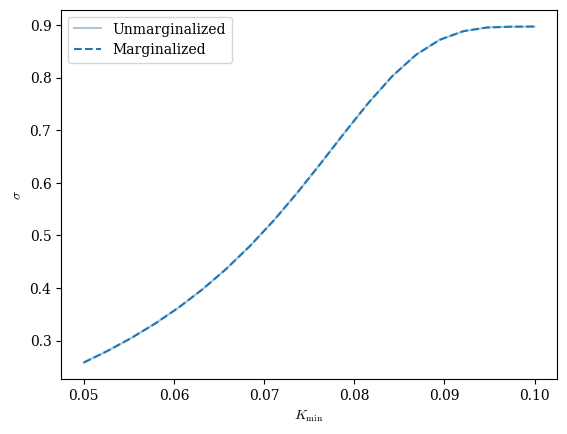

In [62]:
p = plt.plot(modes, err_us, label = "Unmarginalized", alpha = 0.4)
plt.plot(modes, err_ms, label = "Marginalized", ls = "--", color = p[0].get_color())
plt.xlabel(r"$K_{\mathrm{min}}$")
plt.ylabel(r"$\sigma$")
plt.legend()

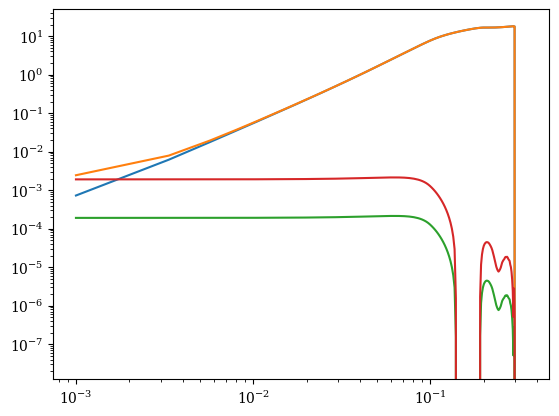

In [34]:
plt.loglog(Ks, get_bias_jax(jnp.array([b1A, b1B, e]), 0))
plt.loglog(Ks, get_bias_jax(jnp.array([b1A, b1B, 10*e]), 0))


plt.loglog(Ks, get_bias_jax(jnp.array([b1A, b1B, e]), 1))
plt.loglog(Ks, get_bias_jax(jnp.array([b1A, b1B, 10*e]), 1))